In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel('Customer Churn Data.xlsx')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# Overview of dataset
df.info()

# Summary statistics for numerical columns
df.describe()

# Checking for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
numerical = ['Age', 'Tenure', 'Balance', 'EstimatedSalary', 'CreditScore']
categorical = ['NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Geography', 'Gender']
target = ['Exited']

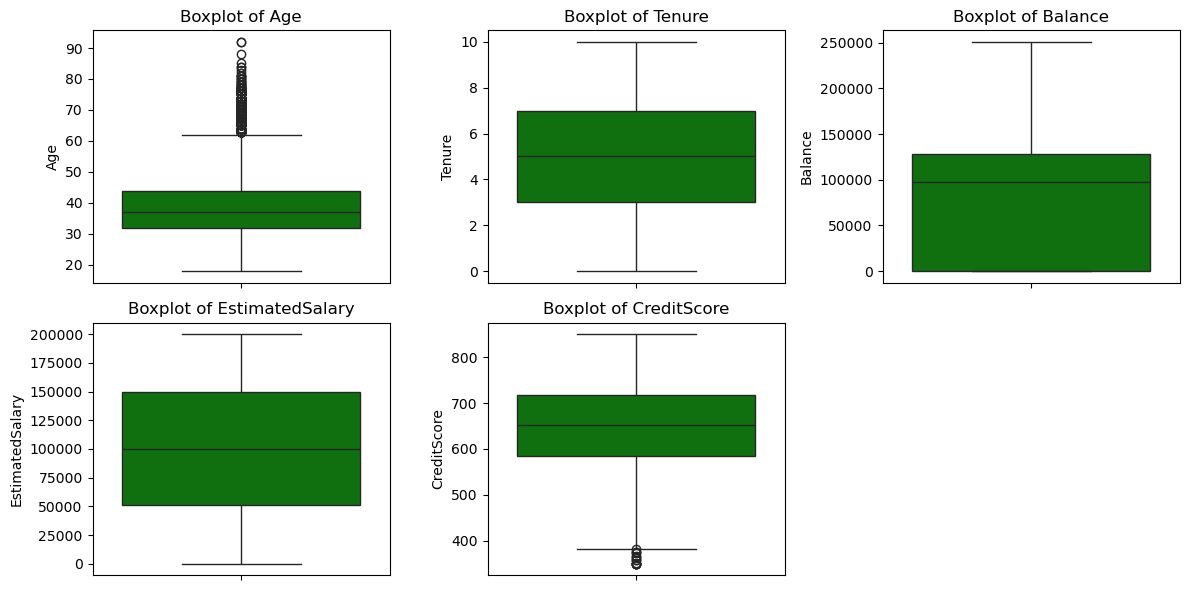

In [11]:
# Univariate Analysis
# Boxplot for Outliers Detection

plt.figure(figsize=(12, 6))

for i, col in enumerate(numerical, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='green')
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

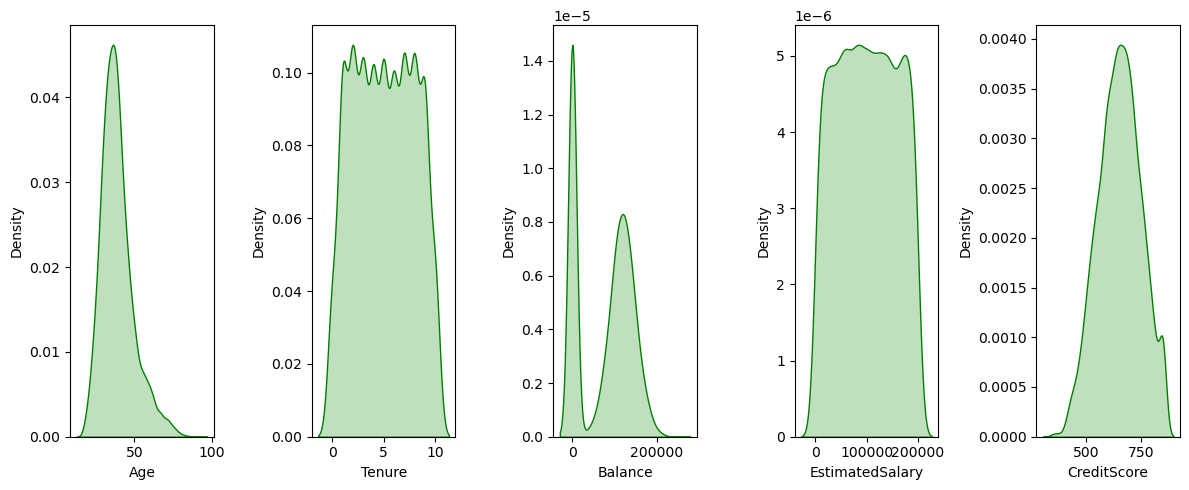

In [13]:
# Distribution Plots for Data Spread
# KDE Plot - Numeric Columns
plt.figure(figsize=(12, 5))

for i, col in enumerate(numerical):
    plt.subplot(1, len(numerical), i + 1)
    sns.kdeplot(df[col], color='green', fill=True)  # Use fill=True instead of shade
    plt.xlabel(col)
    plt.tight_layout()

plt.show()

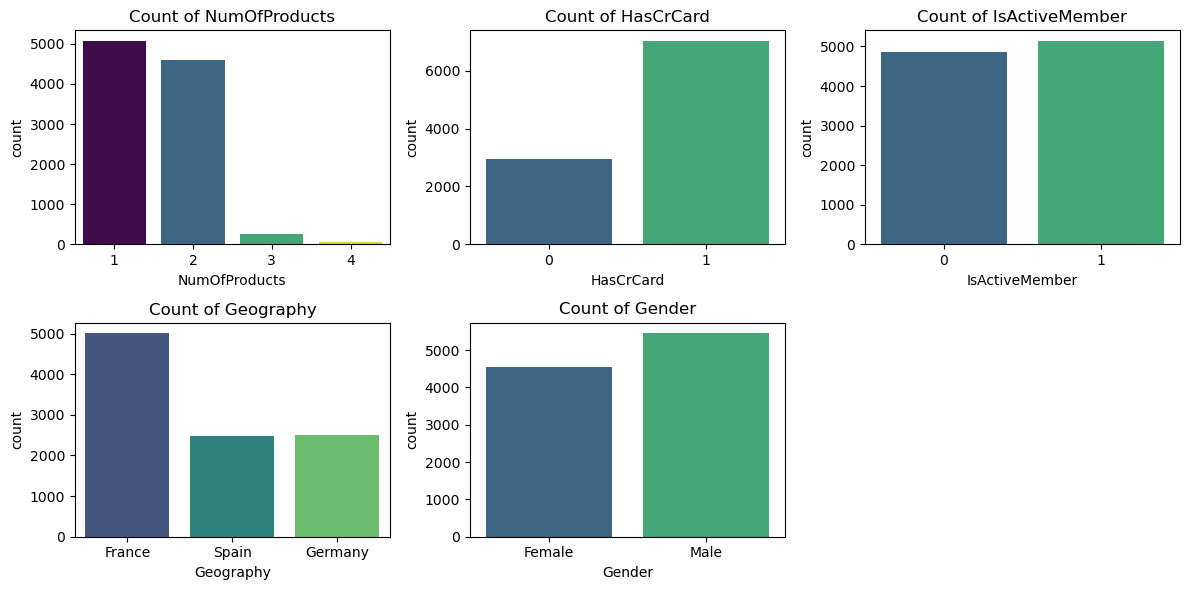

In [15]:
# Categorical Data - Frequency Analysis 
plt.figure(figsize=(12, 6))

for i, col in enumerate(categorical, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f"Count of {col}")

plt.tight_layout()
plt.show()

In [17]:
# Bivariate Analysis
# Churn rate calculation
churn_rate = df['Exited'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 20.37%


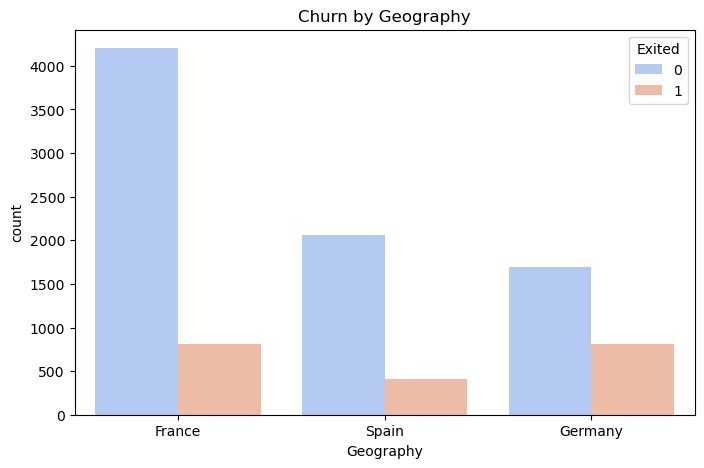

Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64


In [19]:
# Impact of geography on churn
plt.figure(figsize=(8, 5))
sns.countplot(x=df['Geography'], hue=df['Exited'], palette='coolwarm')
plt.title("Churn by Geography")
plt.show()

# Churn rate per geography
print(df.groupby('Geography')['Exited'].mean().sort_values(ascending=False))

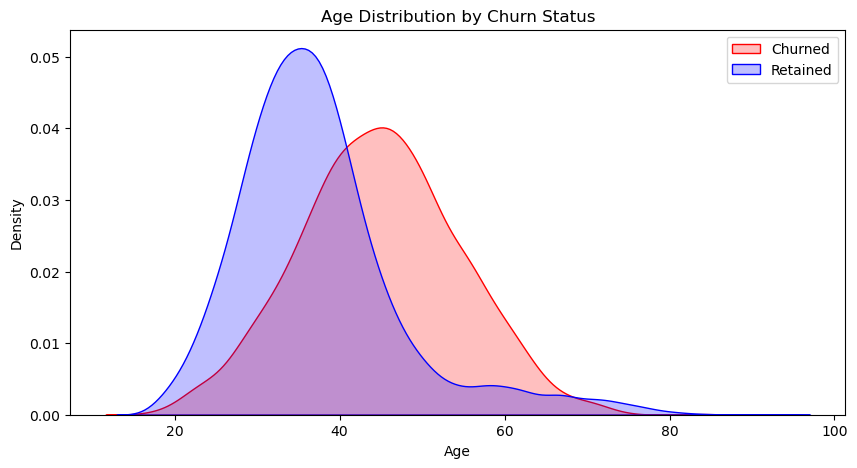

In [21]:
# Age Distribution for Churned vs. Retained Customers
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Exited'] == 1]['Age'], label="Churned", fill=True, color="red")
sns.kdeplot(df[df['Exited'] == 0]['Age'], label="Retained", fill=True, color="blue")
plt.title("Age Distribution by Churn Status")
plt.legend()
plt.show()

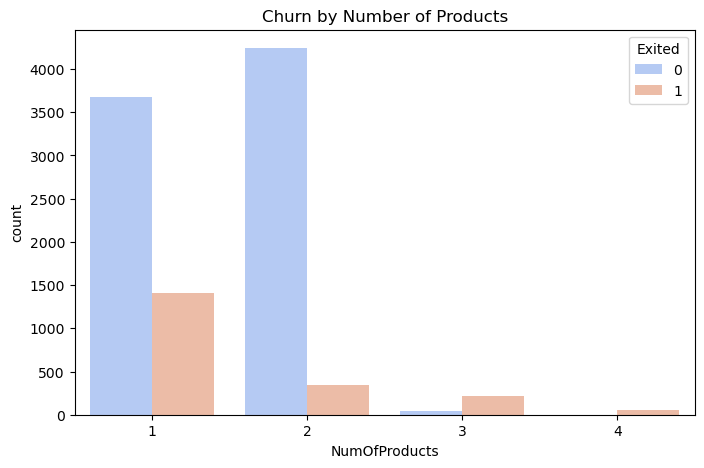

NumOfProducts
4    1.000000
3    0.827068
1    0.277144
2    0.075817
Name: Exited, dtype: float64


In [23]:
# Churn by Number of Products
plt.figure(figsize=(8, 5))
sns.countplot(x=df['NumOfProducts'], hue=df['Exited'], palette='coolwarm')
plt.title("Churn by Number of Products")
plt.show()

# Churn rate by product count
print(df.groupby('NumOfProducts')['Exited'].mean().sort_values(ascending=False))

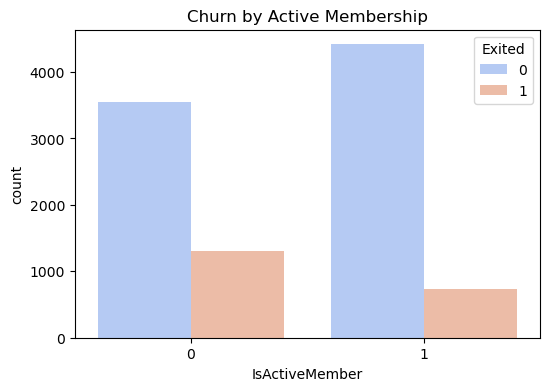

Inactive Churn Rate: 26.85%


In [25]:
# Churn among Inactive Customers
plt.figure(figsize=(6, 4))
sns.countplot(x=df['IsActiveMember'], hue=df['Exited'], palette='coolwarm')
plt.title("Churn by Active Membership")
plt.show()

inactive_churn_rate = df[df['IsActiveMember'] == 0]['Exited'].mean() * 100
print(f"Inactive Churn Rate: {inactive_churn_rate:.2f}%")

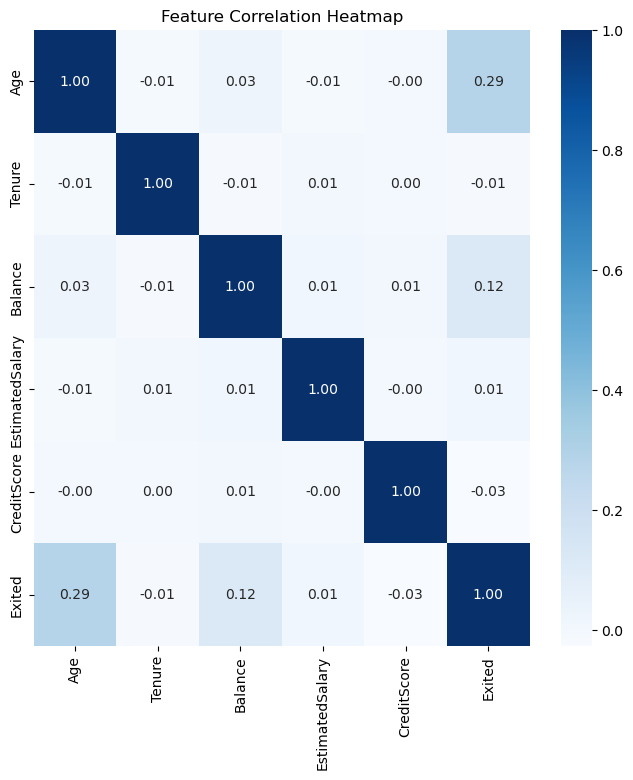

In [27]:
# Correlation Analysis
plt.figure(figsize=(8, 8))
sns.heatmap(df[numerical + target].corr(), cmap='Blues', annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (assuming df is already defined)
# df = pd.read_csv("your_dataset.csv")

# Drop non-relevant columns
columns_to_drop = ["RowNumber", "CustomerId", "Surname"]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1)

### ✅ **Step: Handle One-Hot Encoding (Before Splitting Data)**
columns_to_encode = ["Geography", "Gender"]
existing_columns = [col for col in columns_to_encode if col in df.columns]

if existing_columns:
    df = pd.get_dummies(df, columns=existing_columns, drop_first=True)
else:
    print("Columns already one-hot encoded or missing:", columns_to_encode)

# Print final columns to confirm
print("Columns after encoding:", df.columns)

# Define target variable
X = df.drop("Exited", axis=1)
y = df["Exited"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, algorithm="SAMME", random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)
    acc_score = accuracy_score(y_test, y_pred)

    print(f"{name}:")
    print(f"Accuracy: {acc_score:.4f}")
    print(f"AUC Score: {auc_score:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Columns already one-hot encoded or missing: ['Geography', 'Gender']
Columns after encoding: Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')
Logistic Regression:
Accuracy: 0.8110
AUC Score: 0.5806
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

--------------------------------------------------
Random Forest:
Accuracy: 0.8665
AUC Score: 0.7151
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.

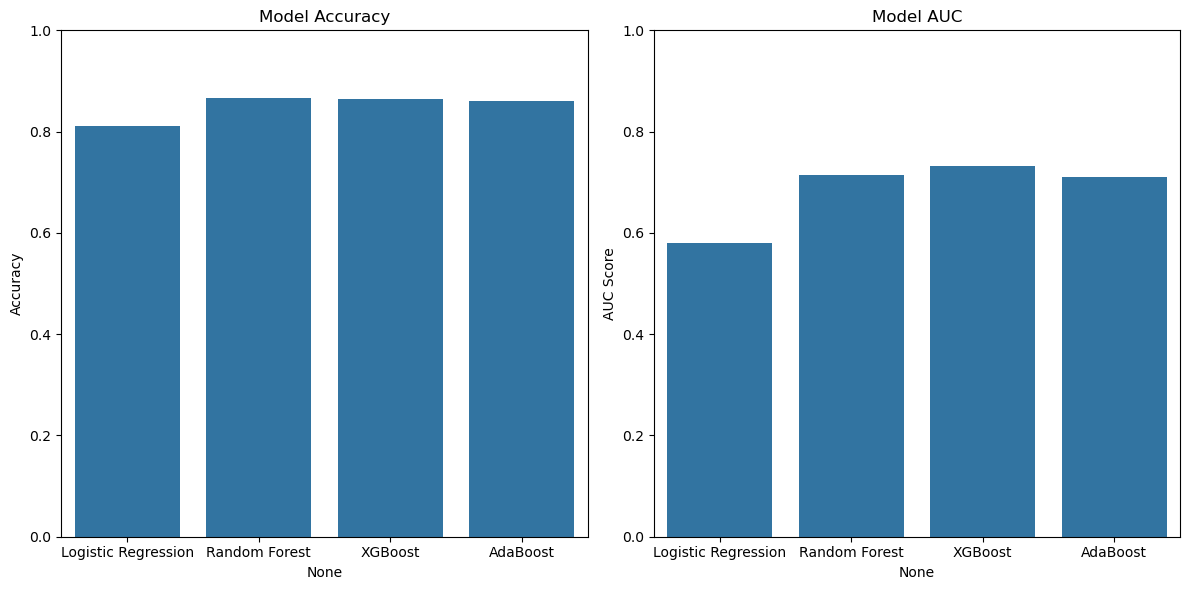

In [73]:
# Collect metrics for comparison
model_metrics = {
    "Logistic Regression": {"Accuracy": 0.8110, "AUC": 0.5806},
    "Random Forest": {"Accuracy": 0.8665, "AUC": 0.7151},
    "XGBoost": {"Accuracy": 0.8640, "AUC": 0.7318},
    "AdaBoost": {"Accuracy": 0.8595, "AUC": 0.7107}
}

# Create DataFrame for plotting
metrics_df = pd.DataFrame(model_metrics).T

# Plot Accuracy and AUC
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Accuracy Plot
sns.barplot(x=metrics_df.index, y=metrics_df["Accuracy"], ax=ax[0])
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim(0, 1)

# AUC Plot
sns.barplot(x=metrics_df.index, y=metrics_df["AUC"], ax=ax[1])
ax[1].set_title('Model AUC')
ax[1].set_ylabel('AUC Score')
ax[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [76]:
# Hypyerparameter for tuning
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')

# Fit GridSearch
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best Score: 0.8651245113490597


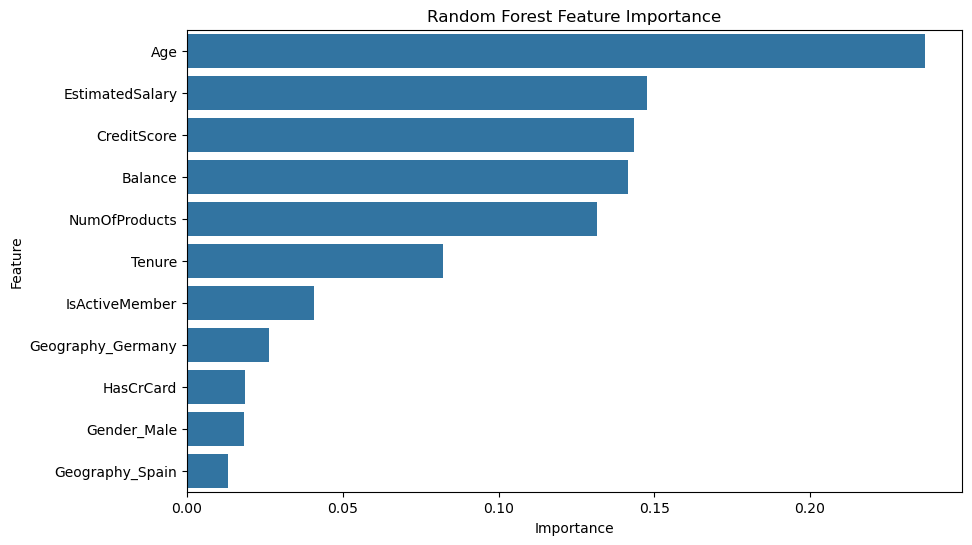

In [78]:
# Feature importance from Random Forest model
feature_importance = models["Random Forest"].feature_importances_

# Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Random Forest Feature Importance')
plt.show()

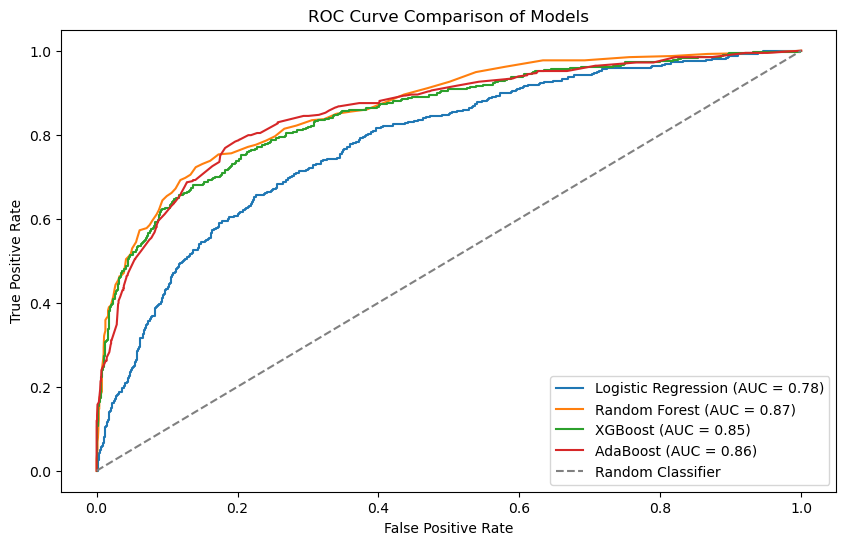

In [82]:
from sklearn.metrics import roc_curve

# Plot ROC curve for each model
plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]  # Probability estimates for class 1
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.title('ROC Curve Comparison of Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

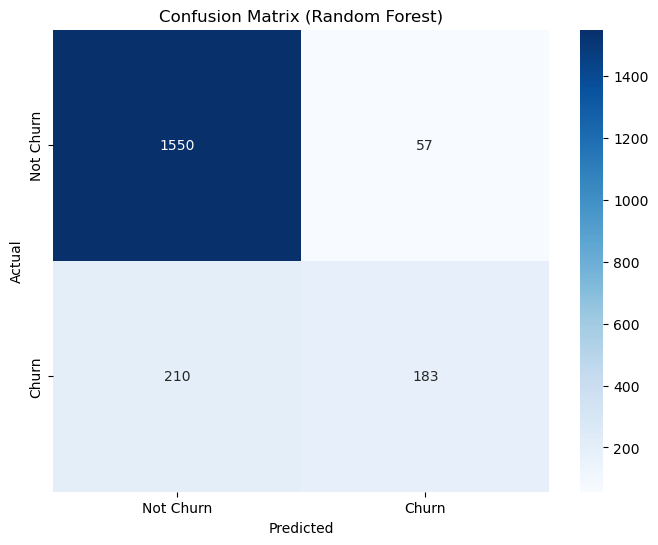

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion Matrix for the best performing model (Random Forest)
y_pred_best = models["Random Forest"].predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

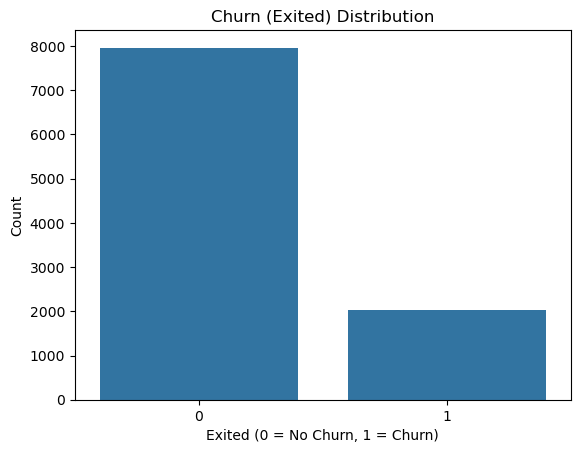

In [86]:
# Plot the distribution of the target variable (Exited)
sns.countplot(x='Exited', data=df)
plt.title('Churn (Exited) Distribution')
plt.xlabel('Exited (0 = No Churn, 1 = Churn)')
plt.ylabel('Count')
plt.show()